In [65]:
import emcee
import numpy as np
import astropy
from astropy.table import QTable, Table, Column
import matplotlib.pyplot as plt
import astropy.visualization.hist
import corner
import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc

In [67]:
transient = np.load("transient.npy")

Text(0, 0.5, 'flux [a.u.]')

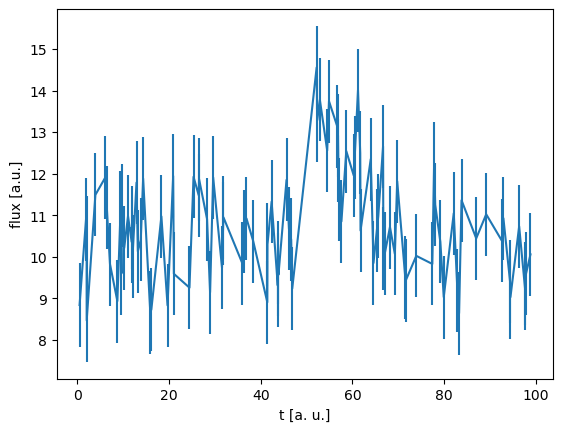

In [69]:
t_data = transient[:, 0]
flux_data = transient[:,1]
sigma_flux_data = transient[:,2]

plt.errorbar(t_data, flux_data, yerr=sigma_flux_data, xerr=None)
plt.xlabel("t [a. u.]")
plt.ylabel("flux [a.u.]")

In [71]:
#model to describe data 
#theta rapresents the parameter 
def model(theta,t):
    b, A, alpha, t0 = theta 
    y = []
    for ti in t:
        if ti < t0:
            y.append(b)
        else:
            y.append(b + A*np.exp(-alpha*(ti-t0)))
    return np.array(y)

In [ ]:
#to avoid problem, better to work with log like, log prior and log posterior 
def loglike(theta):
    """The log-likelihood function."""
    b, A, alpha, t0 = theta
    analitical_model = model(theta, t_data)
    x = flux_data - analitical_model
    return -0.5*np.sum((x)**2/sigma_flux_data**2)

# Define our uniform prior.
t0_min = 0
t0_max = 100
A_min = 0
A_max = 50 
b_min = 0 
b_max = 50 
alpha_min = np.exp(-5)
alpha_max = np.exp(5)
#nb, nestled sampling non vuole il prior logarirmico 
def ptform(u):
    """Transforms samples `u` drawn from the unit cube to samples to those
    from our uniform prior within [a., b.) for each variable."""
    x = np.array(u)  
    x[0] = b_min + (b_max - b_min) * u[0]
    x[1] = A_min + (A_max - A_min) * u[1]
    log_alpha = np.log(alpha_min) + (np.log(alpha_max) - np.log(alpha_min)) * u[2] #prior uniform in log_alpha 
    x[2] = np.exp(log_alpha)
    x[3] = t0_min + (t0_max - t0_min) * u[3]
    return x

In [81]:
# "Static" nested sampling.
sampler = dynesty.NestedSampler(loglike, ptform, 4, nlive=300) 
sampler.run_nested()
sresults = sampler.results

2371it [00:34, 10.53it/s, bound: 98 | nc: 134 | ncall: 48924 | eff(%):  4.846 | loglstar:   -inf < -86.576 <    inf | logz: -93.460 +/-  0.139 | dlogz: 36.210 >  0.309]     C:\Users\User\anaconda3\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
4741it [01:02, 76.27it/s, +300 | bound: 193 | nc: 1 | ncall: 83334 | eff(%):  6.071 | loglstar:   -inf < -48.775 <    inf | logz: -63.293 +/-  0.213 | dlogz:  0.001 >  0.309]


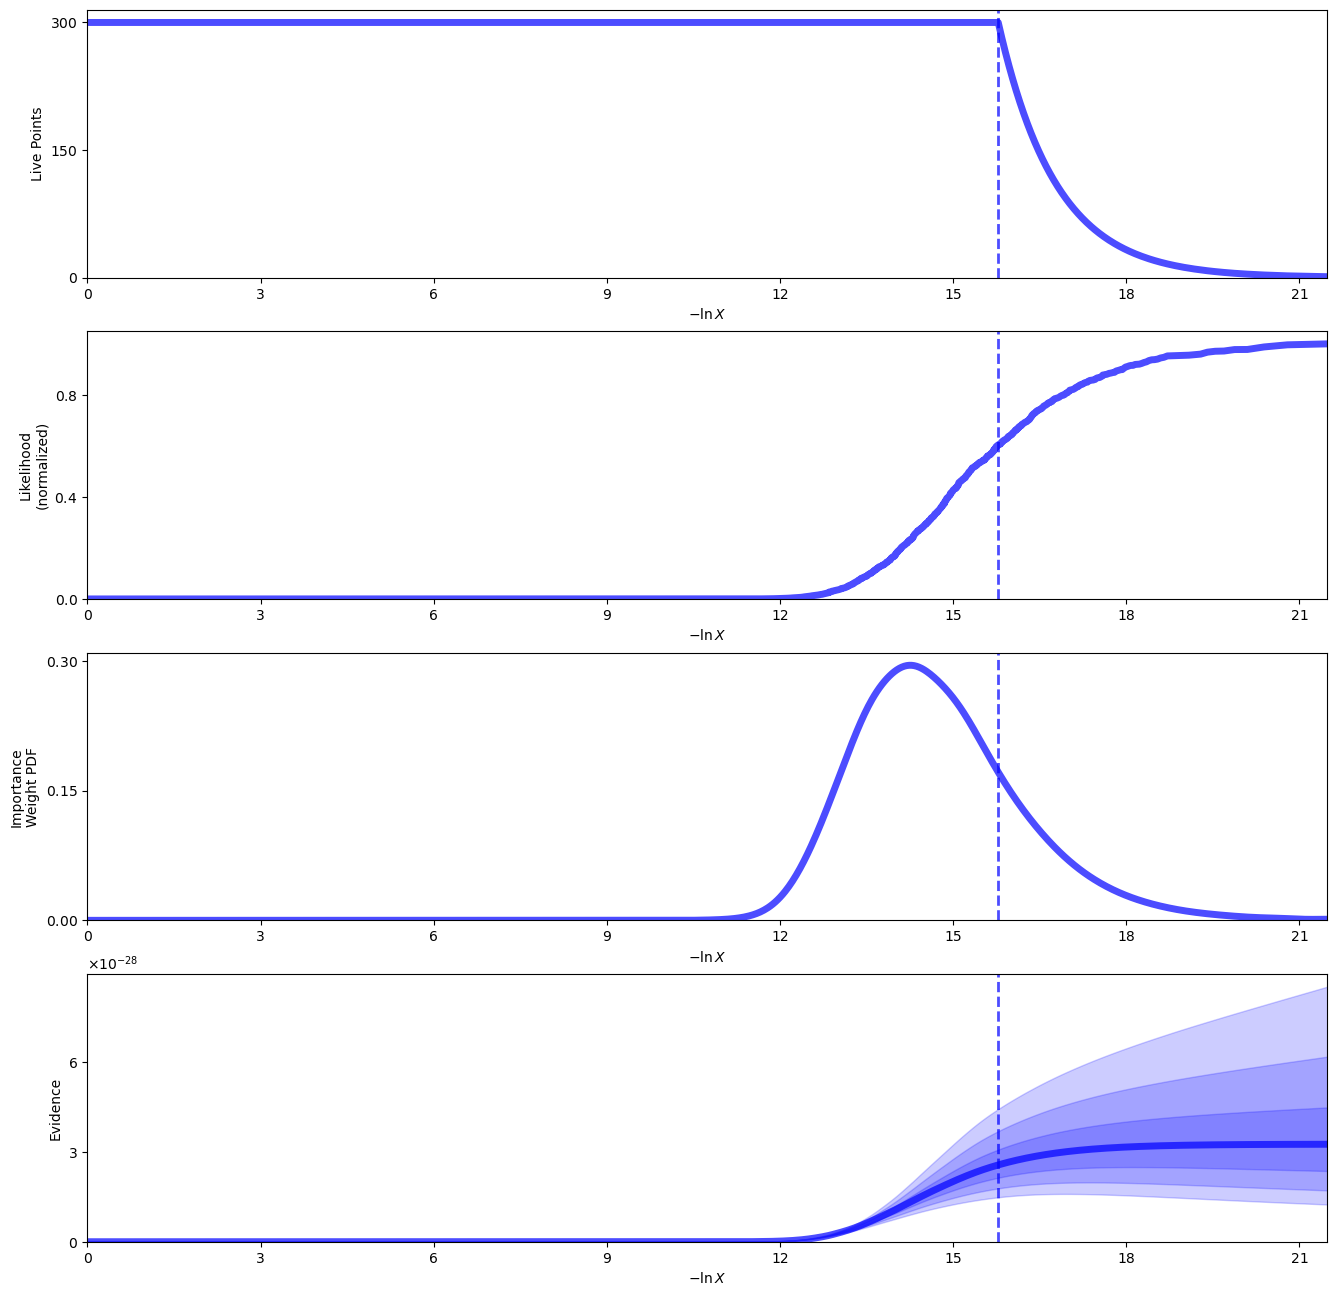

In [83]:
# Plot a summary of the run.
rfig, raxes = dyplot.runplot(sresults)

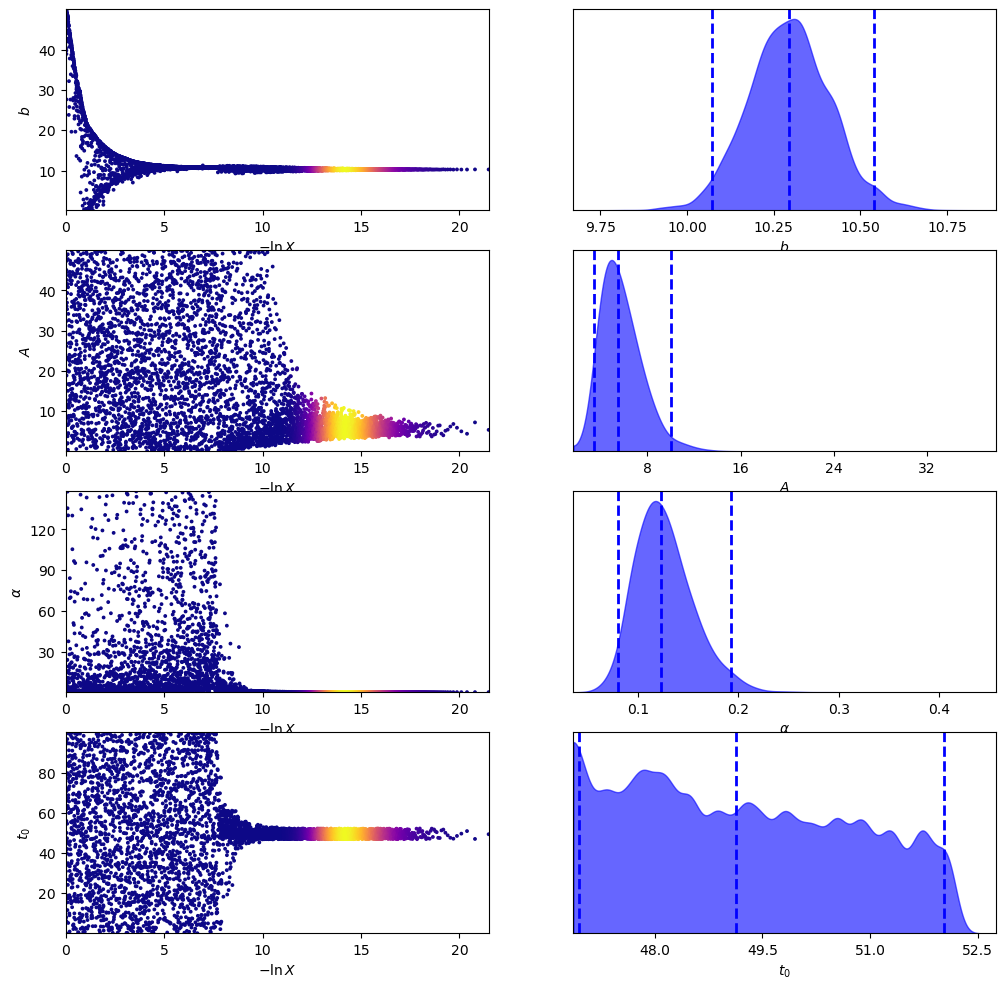

In [85]:
tfig, taxes = dyplot.traceplot(sresults, labels=[r"$b$", r"$A$", r"$\alpha$", r"$t_0$"])

In [87]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights
samples_equal = dyfunc.resample_equal(samples, weights)

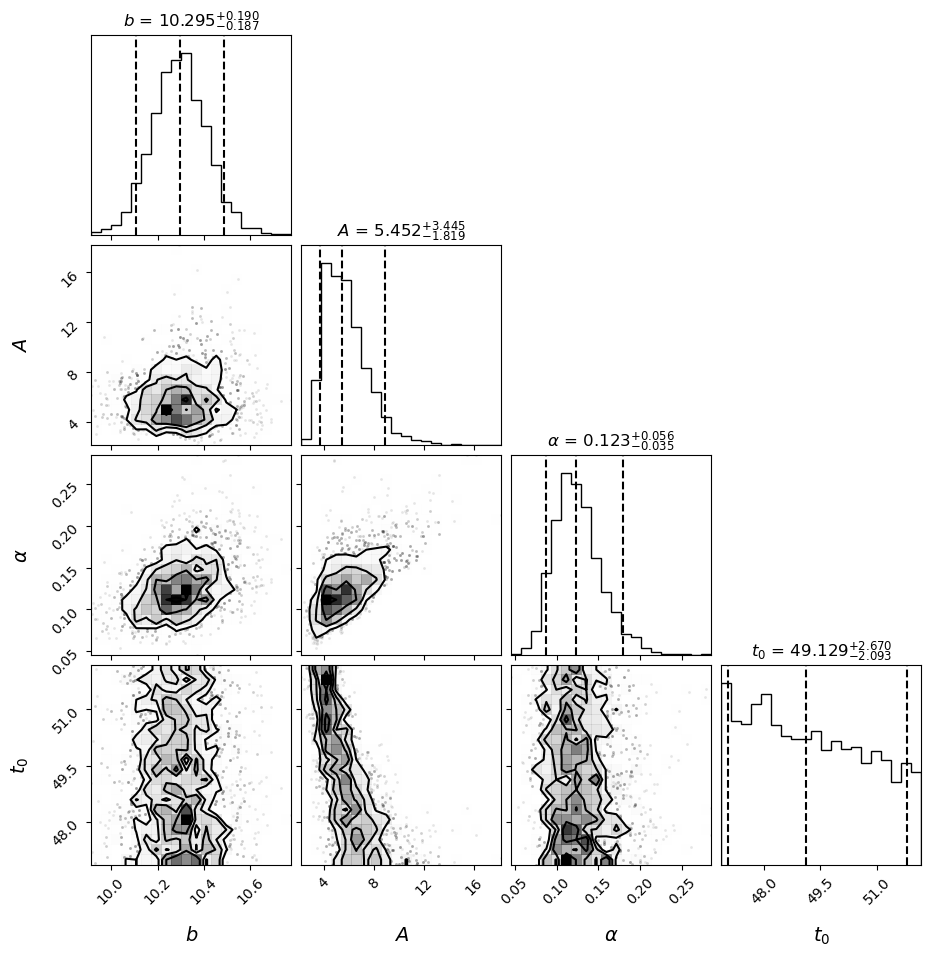

In [89]:
#corner.corner(samples_equal);
fig = corner.corner(
    samples_equal,
    labels=[r"$b$", r"$A$", r"$\alpha$", r"$t_0$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.05, 0.5, 0.95], 
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    plot_contours=True
)

### the same but with a gaussian model 

$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

In [99]:
#definition of a gaussian model
def model_gauss(theta,t):
    b, A,t0,sigmaw = theta 
    return b+A*np.exp(-(((t-t0)/sigmaw)**2 ) / 2)

In [101]:
def loglike(theta):
    """The log-likelihood function."""
    b, A, t0, sigmaw = theta
    analitical_model = model_gauss(theta, t_data)
    x = flux_data - analitical_model
    return -0.5*np.sum((x)**2/sigma_flux_data**2)

In [103]:
# Define our uniform prior.
t0_min = 0
t0_max = 100
A_min = 0
A_max = 50 
b_min = 0 
b_max = 50 
sigmaw_min = np.exp(-2)
sigmaw_max = np.exp(2)
#nb, nestled sampling non vuole il prior logarirmico 
def ptform(u):
    """Transforms samples `u` drawn from the unit cube to samples to those
    from our uniform prior within [a., b.) for each variable.""" 
    x = np.array(u)  
    x[0] = b_min + (b_max - b_min) * u[0]
    x[1] = A_min + (A_max - A_min) * u[1]
    x[2] = t0_min + (t0_max - t0_min) * u[2]
    log_sigmaw = np.log(sigmaw_min) + (np.log(sigmaw_max) - np.log(sigmaw_min)) * u[3]
    x[3] = np.exp(log_sigmaw)
    return x

In [105]:
# "Static" nested sampling.
sampler2 = dynesty.NestedSampler(loglike, ptform,4, nlive=300) 
sampler2.run_nested()
sresults2 = sampler2.results

2373it [00:28,  7.47it/s, bound: 126 | nc: 952 | ncall: 61435 | eff(%):  3.863 | loglstar:   -inf < -86.453 <    inf | logz: -94.210 +/-  0.148 | dlogz: 32.510 >  0.309]  C:\Users\User\anaconda3\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
2380it [00:32,  1.94it/s, bound: 129 | nc: 127 | ncall: 76226 | eff(%):  3.122 | loglstar:   -inf < -86.363 <    inf | logz: -94.189 +/-  0.148 | dlogz: 32.466 >  0.309]C:\Users\User\anaconda3\Lib\site-packages\dynesty\bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uni

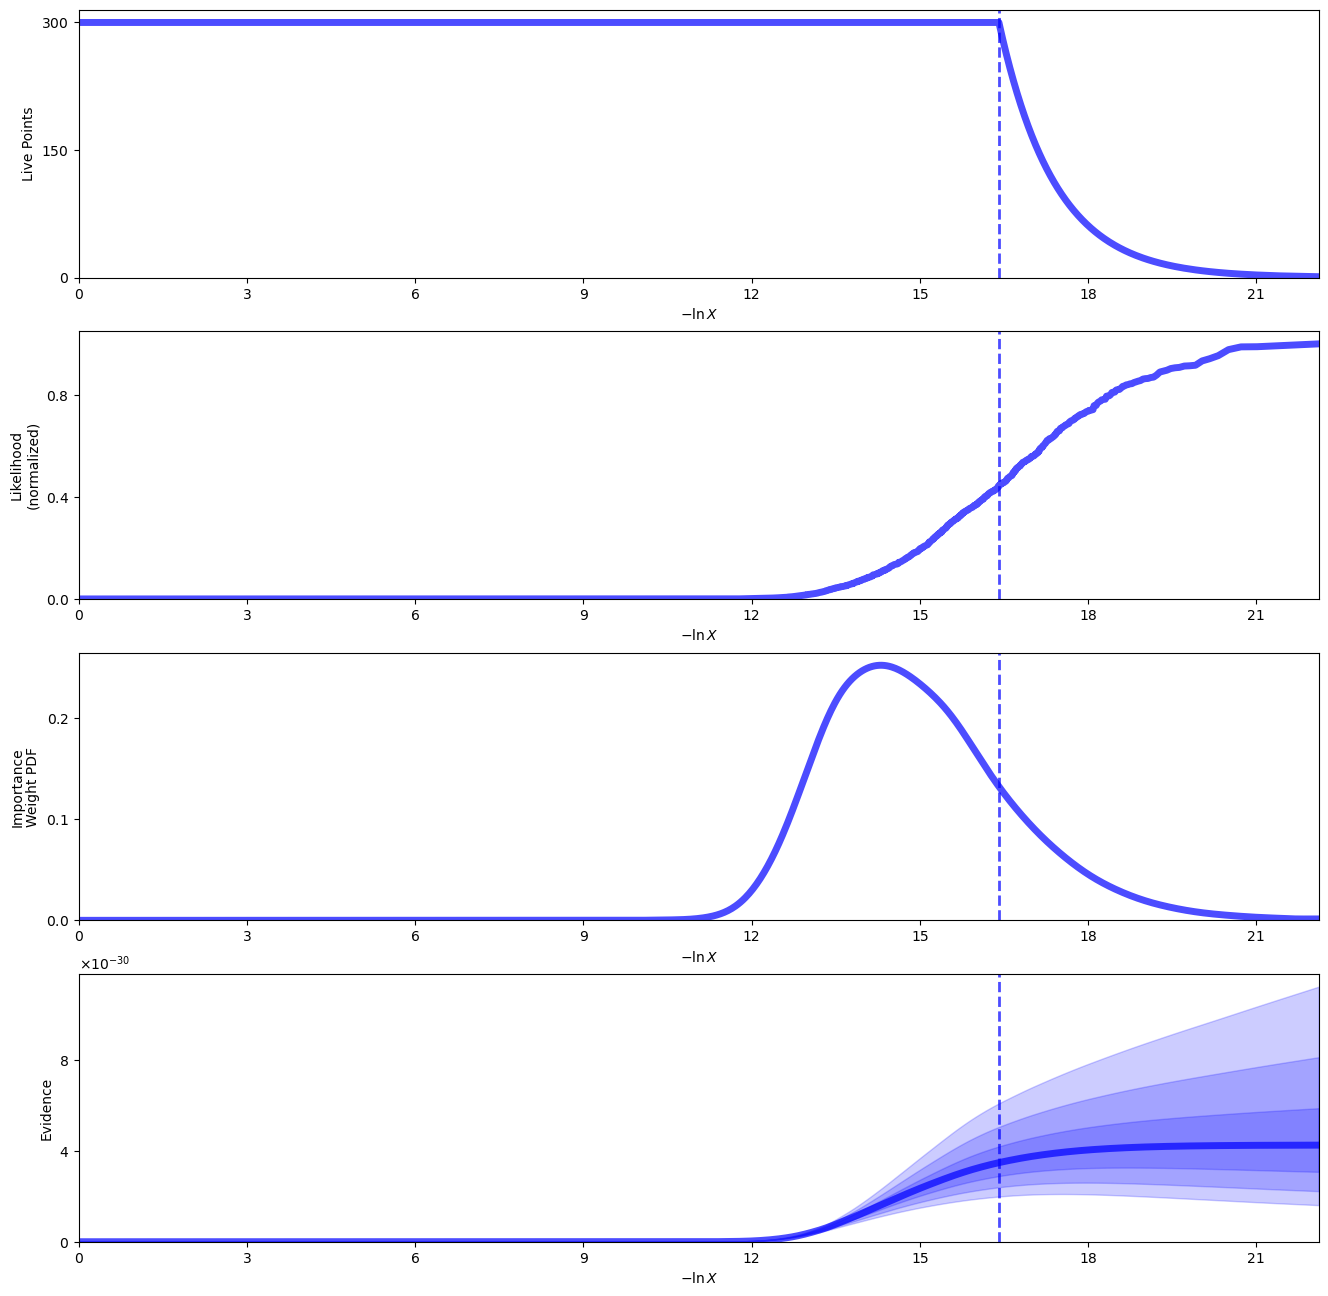

In [109]:
rfig2, raxes2 = dyplot.runplot(sresults2)

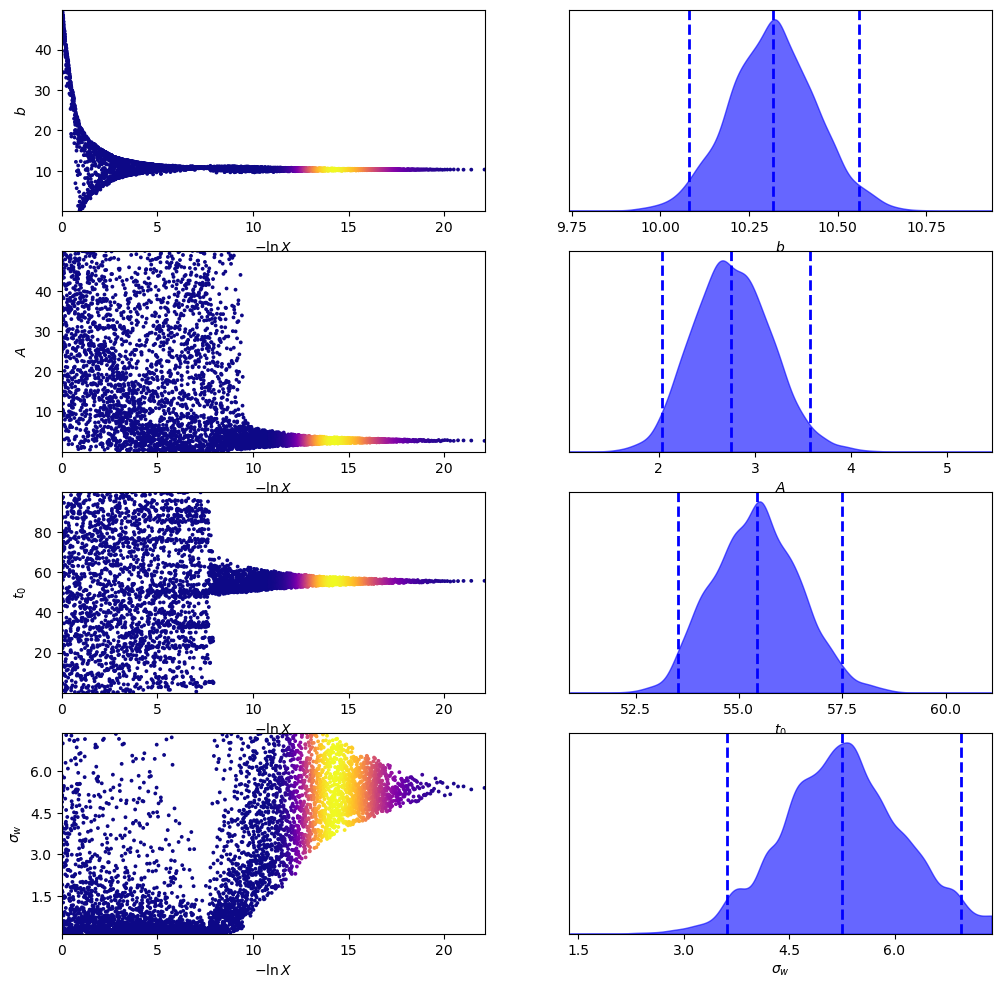

In [111]:
tfig2, taxes2 = dyplot.traceplot(sresults2, labels=[r"$b$", r"$A$", r"$t_0$", r"$\sigma_w$"])

In [113]:
samples2 = sresults2.samples  # samples
weights2 = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights
samples_equal2 = dyfunc.resample_equal(samples2, weights2)

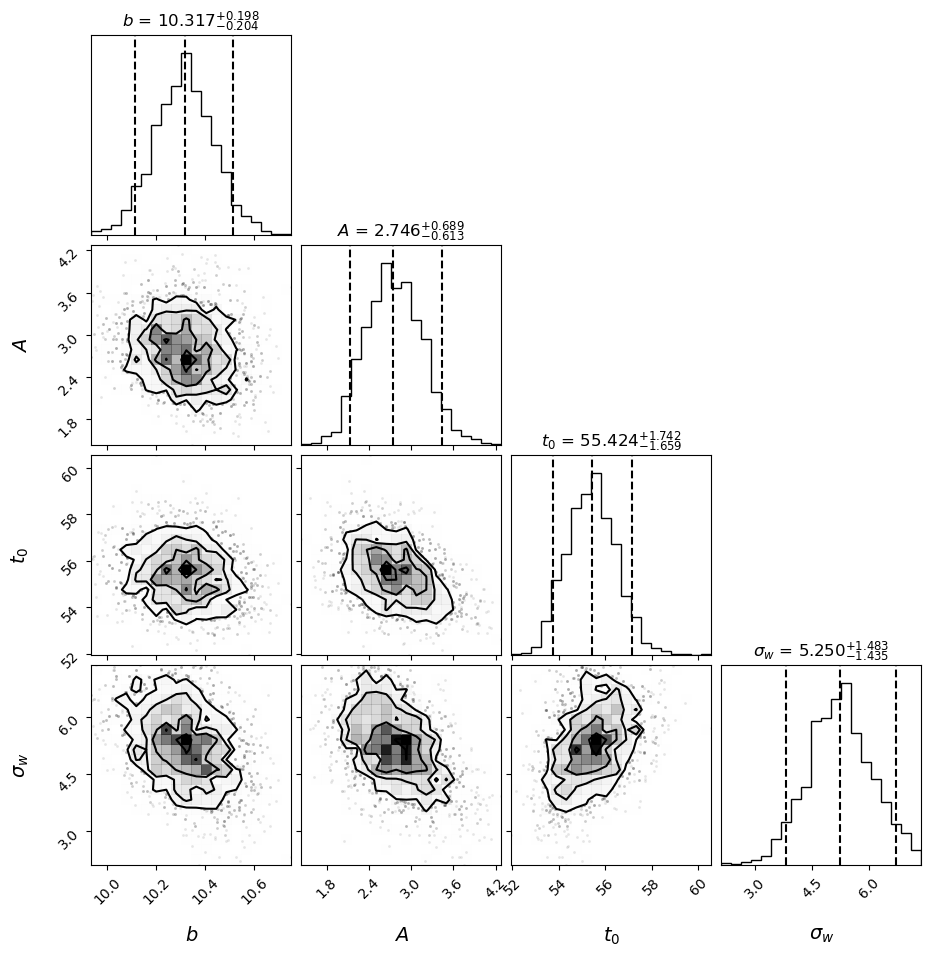

In [115]:
#corner.corner(samples_equal2);
fig = corner.corner(
    samples_equal2,
    labels=[r"$b$", r"$A$", r"$t_0$", r"$\sigma_w$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.05, 0.5, 0.95], #the same as taking the percentile and the median
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    plot_contours=True
)

In [125]:
logZ = sresults.logz[-1] #I take the last element because I upgrade 
logZ2 = sresults2.logz[-1] #Gaussian 

print(logZ)
print(logZ2)

-63.29317229546388
-67.62790476234798


In [127]:
p_z2 = np.exp(logZ2)
p_z1 = np.exp(logZ)
odd_ratio = p_z1/p_z2 #because prior simplify out 

In [129]:
print(odd_ratio) #strong evidence in favour of the burst model! (see jeffrey scale)

76.30454216689138
